<a href="https://colab.research.google.com/github/hubcborja/Trabajo_grado_ECIJG/blob/main/Graficacion_red_convenios_Doble_Tributacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [ ]:
base_convenios=pd.read_csv('/content/data_tax_treaty.csv')
base_convenios.head()

,Country A,Country B,Type,Date of signature,Effective,Status,Source,WHTrates,PE,Other,...,12(2)E,12(A),13(4),13(5),14,16(2),21(3),25B(5),27,29
0,Albania,Israel,Original,2021,2022.0,In Force,0.30,0.31,0.45,0.13,...,5,0,YES,NO,NO,NO,NO,NO,NO,PPT
1,Albania,Turkey,Original,1994,1997.0,In Force,0.19,0.38,0.06,0.13,...,10,0,NO,NO,YES,NO,NO,NO,NO,NaN
2,Albania,Romania,Original,1994,1995.0,In Force,0.47,0.47,0.58,0.38,...,15,0,NO,NO,YES,NO,YES,NO,NO,NaN
3,Albania,Italy,Original,1994,2000.0,In Force,0.19,0.25,0.19,0.13,...,5,0,NO,NO,YES,NO,NO,NO,NO,NaN
4,Albania,Russia,Original,1995,1998.0,In Force,0.23,0.38,0.06,0.25,...,10,0,NO,NO,YES,NO,YES,NO,NO,NaN


In [ ]:
base_convenios.columns

Index(['Country A', 'Country B', 'Type', 'Date of signature', 'Effective',
       'Status', 'Source', 'WHTrates', 'PE', 'Other', 'UN', '5(3)(a)C',
       '5(3)(a)S', '5(3)(b)', '5(4)(a)', '5(4)(b)', '5(5)(b)', '5(6)', '5(7)',
       '7(1)(b&c)', '7(3)', '8(2)', '10(2)(a)Q', '10(2)(a)T', '10(2)(b)',
       '11(2)', '11(2)F', '12(2)', '12(2)C', '12(2)E', '12(A)', '13(4)',
       '13(5)', '14', '16(2)', '21(3)', '25B(5)', '27', '29'],
      dtype='object')

In [ ]:
G = nx.from_pandas_edgelist(base_convenios,
                            source='Country A',
                            target='Country B',
                            edge_attr='Date of signature')

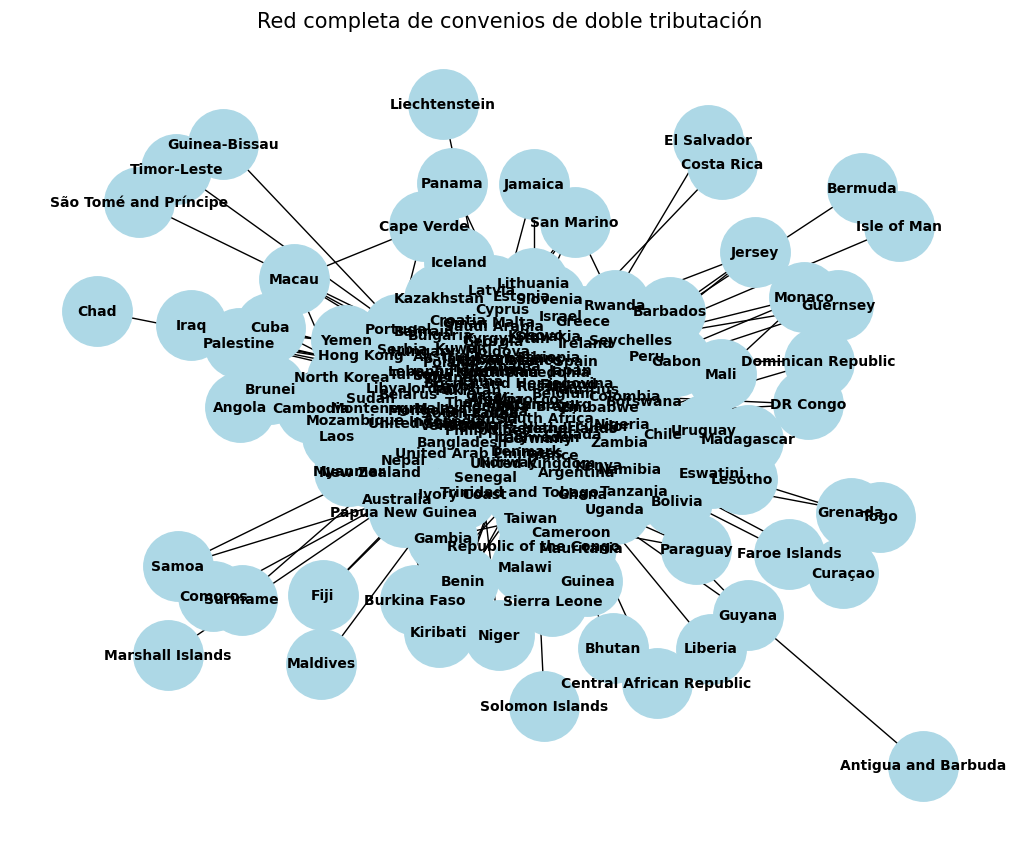

In [ ]:
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2500, font_size=10, font_weight='bold')
plt.title("Red completa de convenios de doble tributación", size=15)
plt.show()

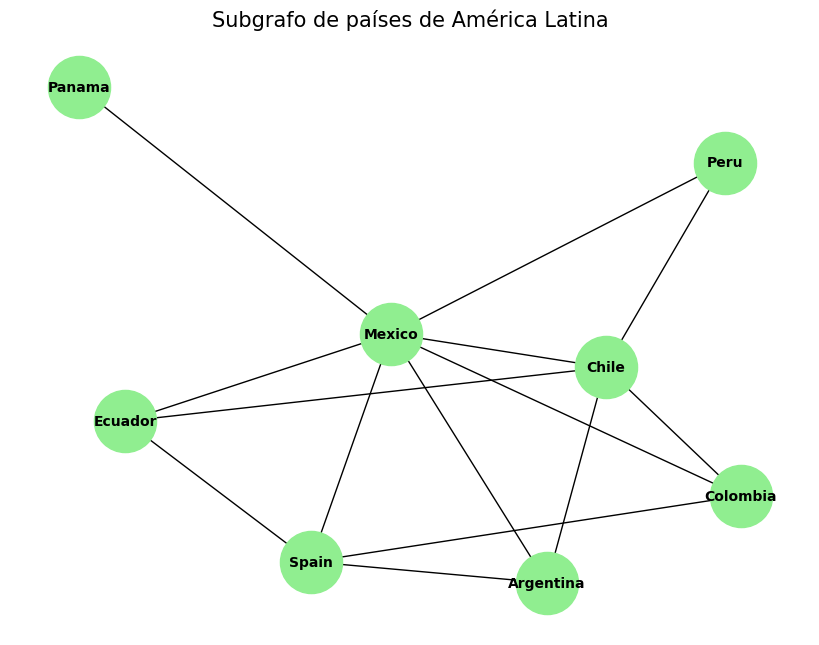

In [ ]:
# Lista de nodos para el subgrafo
paises_subgrafo = ['Mexico', 'Chile', 'Colombia', 'Ecuador', 'Peru', 'Panama', 'Argentina', 'Spain']

# Crear el subgrafo
subgrafo = G.subgraph(paises_subgrafo)

# Dibujar el subgrafo
plt.figure(figsize=(8, 6))
pos_sub = nx.spring_layout(subgrafo, pos=pos)
nx.draw(subgrafo, pos_sub, with_labels=True, node_color='lightgreen', node_size=2000, font_size=10, font_weight='bold')
plt.title("Subgrafo de países de América Latina", size=15)
plt.show()

In [11]:
# Obtener una lista de todos los años únicos de las aristas
anios = [int(d['Date of signature']) for u, v, d in G.edges(data=True)]

# Crear una paleta de colores (colormap)
# Puedes elegir cualquier mapa de colores de Matplotlib, como 'viridis', 'plasma', 'cividis', etc.
cmap = cm.get_cmap('plasma')

# Normalizar los años para que se ajusten al rango del colormap (0 a 1)
min_anio = min(anios)
max_anio = max(anios)
norm = plt.Normalize(vmin=min_anio, vmax=max_anio)
colores_aristas = [cmap(norm(anio)) for anio in anios]

/tmp/ipython-input-1542449225.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma')


ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

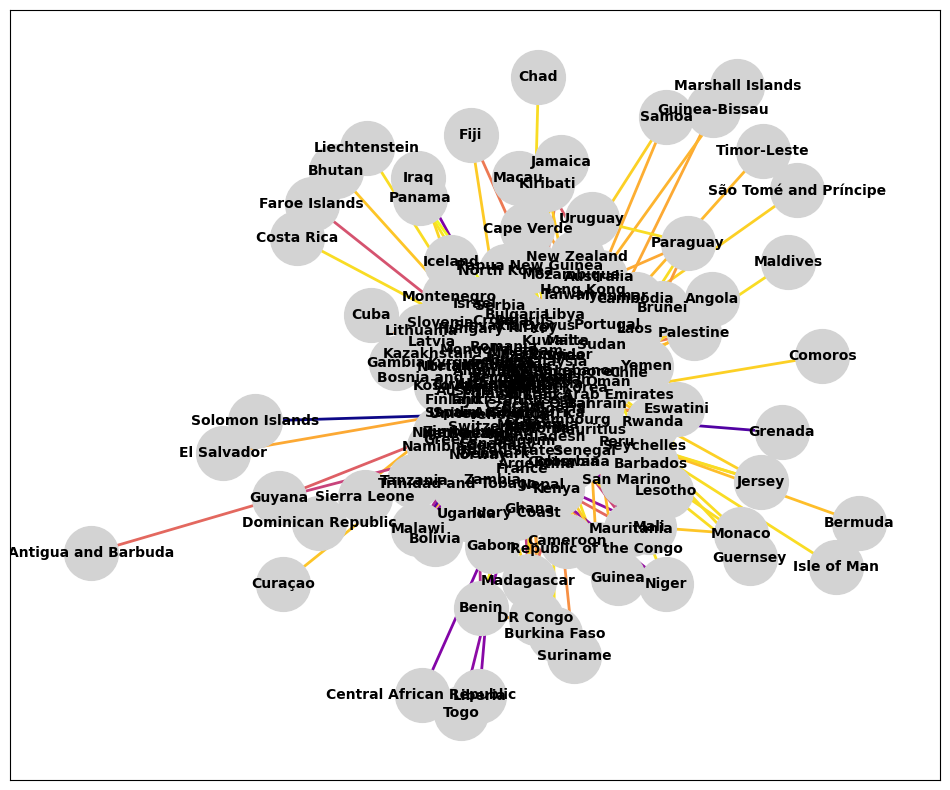

In [12]:
plt.figure(figsize=(12, 10))

# Definir la posición de los nodos
pos = nx.spring_layout(G)

# Dibujar los nodos y sus etiquetas
nx.draw_networkx_nodes(G, pos, node_color='lightgray', node_size=1500)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Dibujar las aristas con los colores asignados
# Es crucial que el orden de edge_color coincida con el de la lista G.edges()
aristas_sorted = list(G.edges(data=True))
colores_aristas_sorted = [cmap(norm(int(d['Date of signature']))) for u, v, d in aristas_sorted]
nx.draw_networkx_edges(G, pos, edgelist=aristas_sorted, edge_color=colores_aristas_sorted, width=2)

# Crear la barra de color
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) # Necesario para que funcione el colorbar
cbar = plt.colorbar(sm, orientation='vertical', shrink=0.7)
cbar.set_label('Año de la firma del convenio')

plt.title("Red de convenios por año de firma", size=15)
plt.axis('off')
plt.show()

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Subgrafo paises vecinos de Colombia

Este grafo representa aquellos paises cercanos a Colombia y los acuerdos para evitar la doble tributación que tienen con otros paises

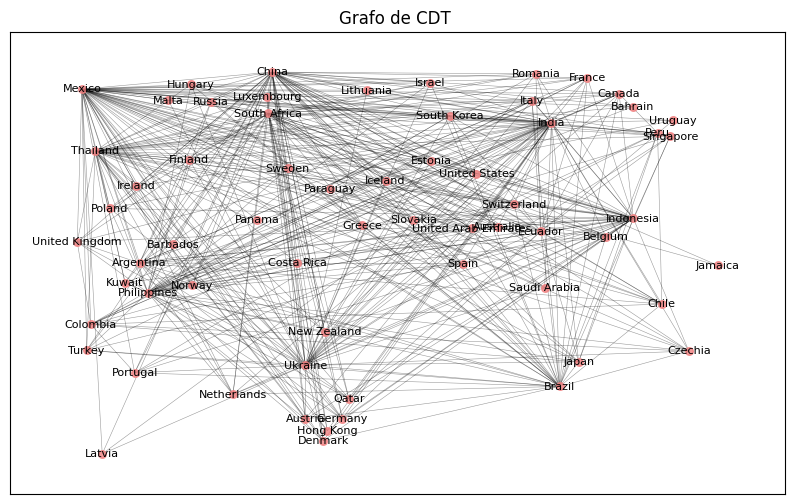

In [31]:
base_convenios=pd.read_csv('/content/drive/MyDrive/Gravity/convenios_tributarios.csv')
base_convenios.head()

paises_subgrafo=['Sweden', 'Malta', 'Australia', 'Czechia', 'Bahrain', 'Latvia', 'Russia', 'New Zealand', 'Ireland', 'Panama', 'Italy', 'Paraguay', 'India',
'Canada', 'Romania', 'Denmark', 'Iceland', 'Turkey', 'South Africa', 'Greece', 'Finland', 'Slovakia', 'Philippines', 'France', 'Argentina',
'Thailand', 'Indonesia', 'Israel', 'China', 'Barbados', 'Costa Rica', 'Belgium', 'Luxembourg', 'Switzerland', 'Lithuania', 'Hong Kong', 'Austria',
'Saudi Arabia', 'Japan', 'Jamaica', 'Hungary', 'Spain', 'United States', 'United Kingdom', 'Colombia', 'Germany', 'United Arab Emirates', 'Peru',
'Estonia', 'Ecuador', 'Brazil', 'Kuwait', 'Singapore', 'South Korea', 'Portugal', 'Qatar', 'Ukraine', 'Uruguay', 'Mexico', 'Poland', 'Norway',
'Chile', 'Netherlands']

G = nx.from_pandas_edgelist(base_convenios,
                            source='Country A',
                            target='Country B')

# Crear el subgrafo
subgrafo = G.subgraph(paises_subgrafo)
# 1. Calcular métrica para tamaño (ej. Degree)
node_degrees = dict(G.degree())
# Escalar el tamaño para la visualización
node_sizes = [v * 50 for v in node_degrees.values()]

# 2. Generar el layout
pos = nx.random_layout(G)
plt.figure(figsize=(10, 6))
# 3. Dibujar el grafo
nx.draw_networkx_nodes(
    subgrafo, pos,
    node_size=30, # Usar el tamaño escalado
    node_color='lightcoral', # Cambiar color
    alpha=0.8
)
nx.draw_networkx_edges(
    subgrafo, pos,
    width=0.4,  # Reducir el grosor de los enlaces (a 0.2)
    alpha=0.4 # Reducir la opacidad
)

nx.draw_networkx_labels(subgrafo, pos, font_size=8)
plt.title("Grafo de CDT ")
plt.show()

In [34]:
metrics = {}

metrics['Degree'] = dict(subgrafo.degree())
metrics['ClosenessCentrality'] = nx.closeness_centrality(subgrafo)
metrics['BetweennessCentrality'] = nx.betweenness_centrality(subgrafo)
metrics['ClusteringCoefficient'] = nx.clustering(subgrafo)
metrics['Eccentricity'] = nx.eccentricity(subgrafo)
metrics['NeighborhoodConnectivity'] = nx.average_neighbor_degree(subgrafo)
metrics['Stress'] = nx.load_centrality(subgrafo)

# --- Métricas Globales (No por nodo, sino para la red completa) ---
try:
    avg_path = nx.average_shortest_path_length(subgrafo)
    print(f"AverageShortestPathLength: {avg_path}")
except nx.NetworkXError:
    # Esto ocurre si la red no está conectada (importante para tu tesis!)
    print("La red no está conectada, no se puede calcular ASPL.")

# --- Métricas Simples y de Estructura ---
print(f"NumberOfUndirectedEdges: {subgrafo.number_of_edges()}")
print(f"SelfLoops: {nx.number_of_selfloops(subgrafo)}")

# --- Conversión a DataFrame para integrar con atributos de nodo (OE2) ---
df_metrics = pd.DataFrame(metrics)
# El índice del DataFrame son los países (nodos)

print("\nDataFrame de Métricas Estructurales (Primeras filas):")
print(df_metrics.head())

AverageShortestPathLength: 1.8023553507424475
NumberOfUndirectedEdges: 434
SelfLoops: 0

DataFrame de Métricas Estructurales (Primeras filas):
             Degree  ClosenessCentrality  BetweennessCentrality  \
Czechia          10             0.539130               0.000416   
Colombia         13             0.558559               0.003211   
Australia         8             0.529915               0.000221   
Greece            5             0.516667               0.000000   
Philippines      37             0.712644               0.033053   

             ClusteringCoefficient  Eccentricity  NeighborhoodConnectivity  \
Czechia                   0.733333             3                 42.400000   
Colombia                  0.294872             2                 18.384615   
Australia                 0.714286             3                 44.000000   
Greece                    1.000000             3                 51.800000   
Philippines               0.276276             2                

In [38]:
jaccard_scores = nx.jaccard_coefficient(subgrafo)

# 3. Almacenar los resultados en una lista o DataFrame
scores_list = []
for u, v, p in jaccard_scores:
    # 'p' es la probabilidad/puntuación de Jaccard
    scores_list.append({'Pais_i': u, 'Pais_j': v, 'Jaccard_Score': p})

df_jaccard = pd.DataFrame(scores_list)
df_jaccard.sort_values(by=['Pais_i','Jaccard_Score'], ascending=[True, False], inplace=True)

In [39]:
df_jaccard

,Pais_i,Pais_j,Jaccard_Score
446,Argentina,Ecuador,0.500000
454,Argentina,South Africa,0.434783
419,Argentina,Indonesia,0.428571
427,Argentina,Thailand,0.386364
432,Argentina,India,0.377358
...,...,...,...
1122,Uruguay,Finland,0.166667
1123,Uruguay,Bahrain,0.142857
1124,Uruguay,Peru,0.090909
1120,Uruguay,Ukraine,0.042553
